# 1. Upload and Load Dataset


In [3]:
from google.colab import files
uploaded = files.upload()


Saving sampled_dataset2.csv to sampled_dataset2.csv


# 2. Data Cleaning and Preprocessing

In [5]:
import pandas as pd

# For Excel files
df = pd.read_csv("sampled_dataset2.csv")

# Drop identifier/IP columns
columns_to_drop = ['session', 'source_IP_address', 'Destination_IP_address']
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

# Drop constant/zero-variance features
nunique = df.nunique()
constant_cols = nunique[nunique <= 1].index.tolist()
df.drop(columns=constant_cols, inplace=True)

df.shape


(50000, 98)

# 3. Feature and Label Separation


In [6]:
X = df.drop(columns=['label'])
y = df['label']


In [7]:
# Replace 'label' with your actual label column if different
X = df.drop(columns=['label'])
y = df['label']


# 4. Feature Scaling and Selection


In [8]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

selector = SelectKBest(score_func=f_classif, k=50)
X_selected = selector.fit_transform(X_scaled, y)

selected_features = X.columns[selector.get_support()]
print("Selected Features:\n", selected_features)


Selected Features:
 Index(['Flag_of_packets', 'Payload_ratio', 'Length_of_TCP_packet_header',
       'TCP_windows_size_value', 'flow duration', 'mean_Length_of_IP_packets',
       'median_Length_of_IP_packets', 'max_Length_of_IP_packets',
       'min_Length_of_IP_packets', 'std_Length_of_IP_packets',
       'var_Length_of_IP_packets', 'mean_Length_of_TCP_payload',
       'median_Length_of_TCP_payload', 'max_Length_of_TCP_payload',
       'std_Length_of_TCP_payload', 'var_Length_of_TCP_payload',
       'mean_Length_of_TCP_packet_header',
       'median_Length_of_TCP_packet_header', 'max_Length_of_TCP_packet_header',
       'min_Length_of_TCP_packet_header', 'std_Length_of_TCP_packet_header',
       'var_Length_of_TCP_packet_header', 'mean_TCP_windows_size_value',
       'median_TCP_windows_size_value', 'max_TCP_windows_size_value',
       'min_TCP_windows_size_value', 'mean_Length_of_TCP_segment(packet)',
       'median_Length_of_TCP_segment(packet)',
       'max_Length_of_TCP_segment(p

# 5. Train-Test Split


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.3, random_state=42)


# 6. Model Training – Machine Learning (Random Forest and SVM)


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

svm = SVC(kernel='rbf', probability=True)
svm.fit(X_train, y_train)
svm_preds = svm.predict(X_test)

print("Random Forest:\n", classification_report(y_test, rf_preds))
print("SVM:\n", classification_report(y_test, svm_preds))


Random Forest:
               precision    recall  f1-score   support

           0       0.92      0.91      0.92      7768
           1       0.91      0.92      0.91      7232

    accuracy                           0.91     15000
   macro avg       0.91      0.91      0.91     15000
weighted avg       0.91      0.91      0.91     15000

SVM:
               precision    recall  f1-score   support

           0       0.81      0.88      0.85      7768
           1       0.86      0.78      0.82      7232

    accuracy                           0.83     15000
   macro avg       0.84      0.83      0.83     15000
weighted avg       0.84      0.83      0.83     15000



# 7. Deep Learning – CNN and LSTM


In [11]:
#Preprocessing
from tensorflow.keras.utils import to_categorical

X_dl = scaler.fit_transform(X_selected)
X_dl = X_dl.reshape(X_dl.shape[0], X_dl.shape[1], 1)
y_cat = to_categorical(y)


# CNN Model

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

cnn = Sequential([
    Conv1D(64, 3, activation='relu', input_shape=(X_dl.shape[1], 1)),
    MaxPooling1D(2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(2, activation='softmax')
])
cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn.fit(X_dl, y_cat, epochs=10, batch_size=32, validation_split=0.2)


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7426 - loss: 0.4767 - val_accuracy: 0.8231 - val_loss: 0.3469
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8166 - loss: 0.3580 - val_accuracy: 0.8062 - val_loss: 0.3273
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8291 - loss: 0.3299 - val_accuracy: 0.8384 - val_loss: 0.3096
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8380 - loss: 0.3143 - val_accuracy: 0.8411 - val_loss: 0.2913
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8364 - loss: 0.3087 - val_accuracy: 0.8529 - val_loss: 0.2855
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8451 - loss: 0.2984 - val_accuracy: 0.8569 - val_loss: 0.2836
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8452 - loss: 0.3004 - val_accuracy: 0.8566 - val_loss: 0.2757
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8469 - loss: 0.2924 - val_accur

# LSTM Model

In [13]:
from tensorflow.keras.layers import LSTM

lstm = Sequential([
    LSTM(64, input_shape=(X_dl.shape[1], 1)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(2, activation='softmax')
])
lstm.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
lstm.fit(X_dl, y_cat, epochs=10, batch_size=32, validation_split=0.2)


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 27s 20ms/step - accuracy: 0.6778 - loss: 0.5946 - val_accuracy: 0.7303 - val_loss: 0.5037
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 40s 20ms/step - accuracy: 0.7335 - loss: 0.5061 - val_accuracy: 0.7546 - val_loss: 0.4648
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - accuracy: 0.7569 - loss: 0.4598 - val_accuracy: 0.7861 - val_loss: 0.4218
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - accuracy: 0.7836 - loss: 0.4232 - val_accuracy: 0.7748 - val_loss: 0.4002
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.7900 - loss: 0.4045 - val_accuracy: 0.8180 - val_loss: 0.3703
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.8034 - loss: 0.3844 - val_accuracy: 0.8238 - val_loss: 0.3585
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - accuracy: 0.8077 - loss: 0.3762 - val_accuracy: 0.8264 - val_loss: 0.3502
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 40s 20ms/step - accuracy: 0.8135 - loss: 0.36

# 8. Accuracy Comparison Visualization


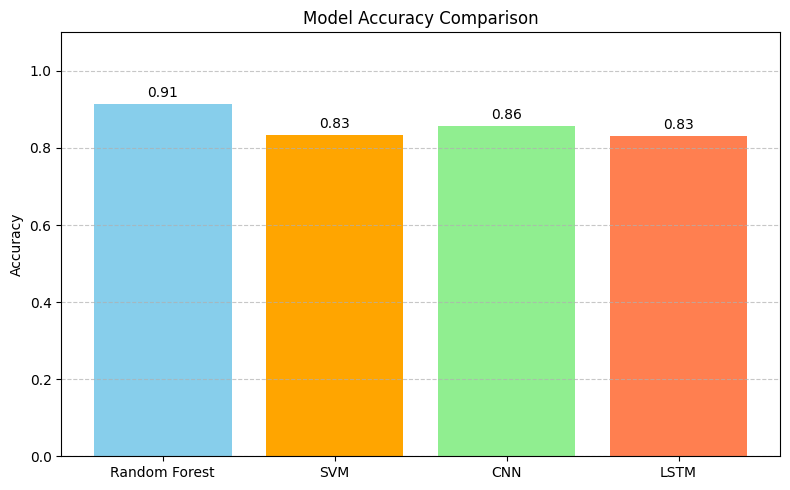

In [14]:
#import all the Metrics
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_recall_curve, roc_curve, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_score, recall_score
)
import matplotlib.pyplot as plt
import seaborn as sns

# Get model accuracies
rf_acc = rf.score(X_test, y_test)
svm_acc = svm.score(X_test, y_test)
cnn_loss, cnn_acc = cnn.evaluate(X_dl, y_cat, verbose=0)
lstm_loss, lstm_acc = lstm.evaluate(X_dl, y_cat, verbose=0)


model_names = ['Random Forest', 'SVM', 'CNN', 'LSTM']
accuracies = [rf_acc, svm_acc, cnn_acc, lstm_acc]

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies, color=['skyblue', 'orange', 'lightgreen', 'coral'])
plt.ylim(0, 1.1)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f"{yval:.2f}", ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [15]:
def evaluate_model(y_true, y_pred, y_prob, model_name="Model"):
    print(f"--- {model_name} Evaluation ---")

    # Accuracy
    acc = accuracy_score(y_true, y_pred)
    print(f"Accuracy: {acc:.4f}")

    # Precision and Recall
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")

    # ROC AUC
    auc = roc_auc_score(y_true, y_prob)
    print(f"ROC AUC: {auc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # Precision-Recall Curve
    precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_prob)
    plt.plot(recall_vals, precision_vals, marker='.', label=f'{model_name}')
    plt.title(f"{model_name} Precision-Recall Curve")
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.grid(True)
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.plot(fpr, tpr, marker='.', label=f'{model_name}')
    plt.plot([0,1], [0,1], linestyle='--')  # Diagonal line
    plt.title(f"{model_name} ROC Curve")
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid(True)
    plt.show()


#Random Forest

--- Random Forest Evaluation ---
Accuracy: 0.9143
Precision: 0.9053
Recall: 0.9184
ROC AUC: 0.9801


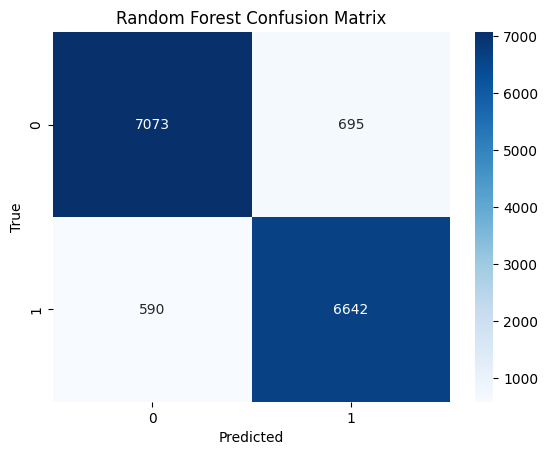

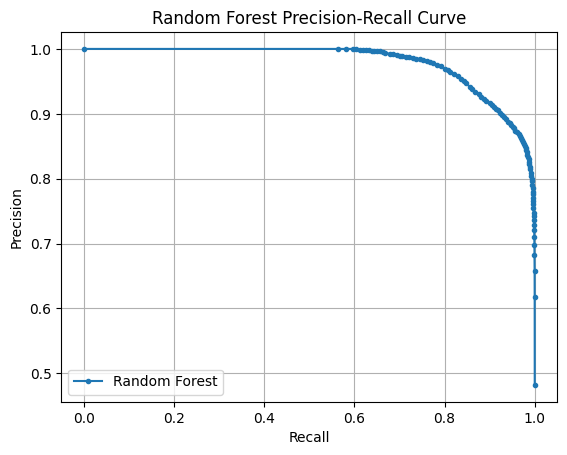

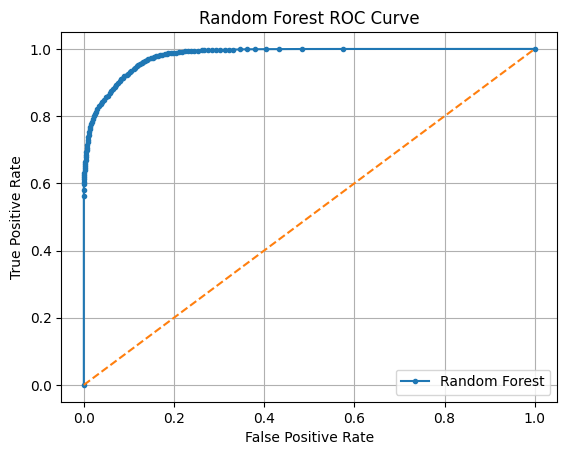

In [16]:
rf_probs = rf.predict_proba(X_test)[:, 1]  # Probability for positive class (malicious)
evaluate_model(y_test, rf_preds, rf_probs, model_name="Random Forest")


#SVM


--- SVM Evaluation ---
Accuracy: 0.8337
Precision: 0.8612
Recall: 0.7810
ROC AUC: 0.9211


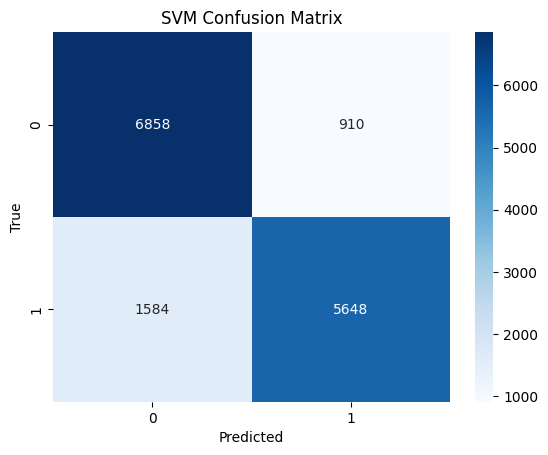

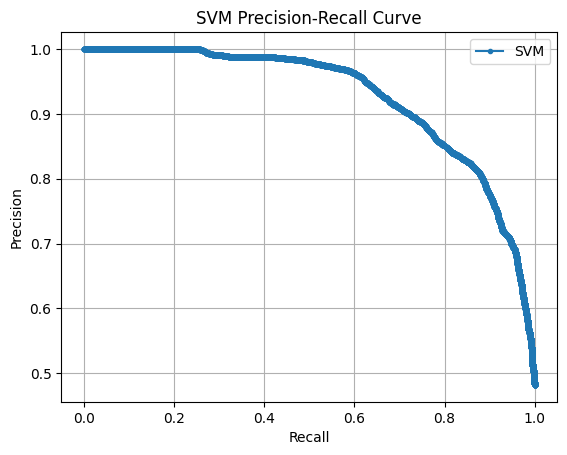

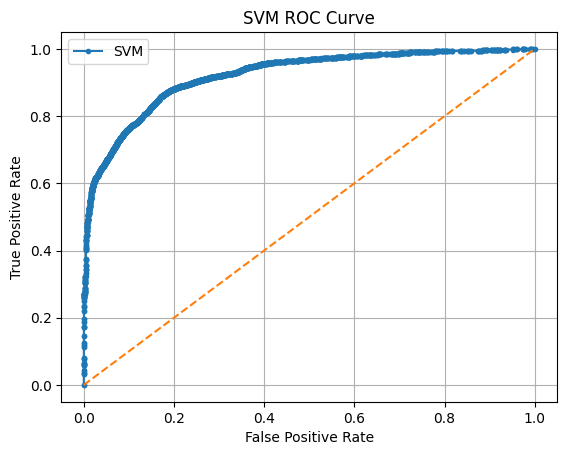

In [17]:
svm_probs = svm.predict_proba(X_test)[:, 1]  # SVM also returns probabilities
evaluate_model(y_test, svm_preds, svm_probs, model_name="SVM")


#CNN & LSTM

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step
--- CNN Evaluation ---
Accuracy: 0.8567
Precision: 0.8375
Recall: 0.8748
ROC AUC: 0.9490


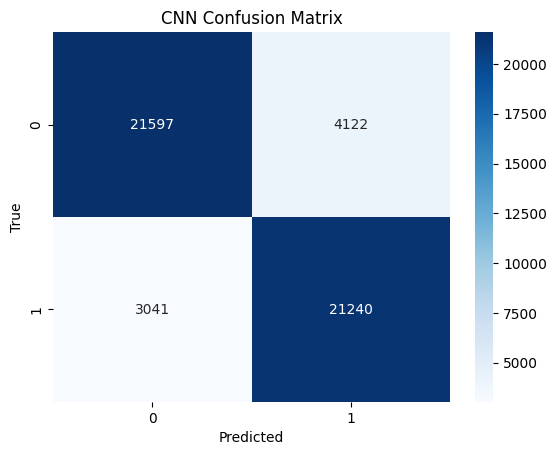

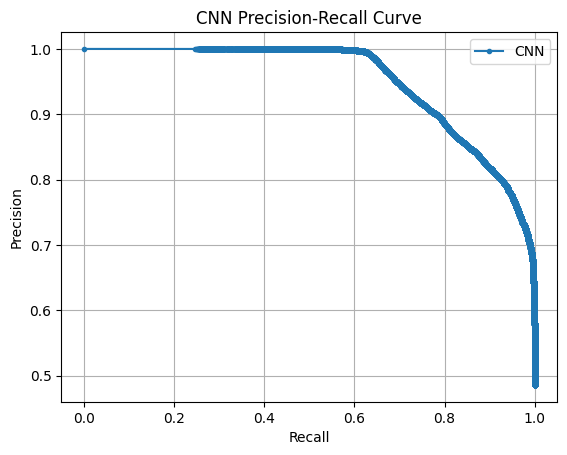

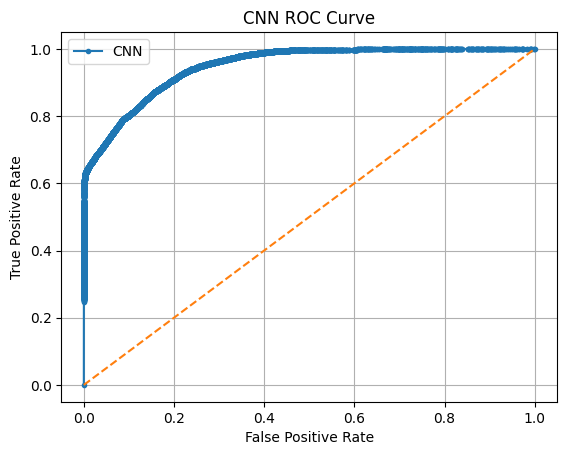

In [19]:
cnn_preds_prob = cnn.predict(X_dl)
cnn_preds_class = cnn_preds_prob.argmax(axis=1)
evaluate_model(y, cnn_preds_class, cnn_preds_prob[:,1], model_name="CNN")
